## Import libs

In [1]:
from tensorflow.python.data import Dataset
from sklearn.model_selection import train_test_split
import seaborn as sns
import pandas as pd


from falsb4mpa.dataset.load_data import load_data
from falsb4mpa.evaluation.evaluation import compute_predictive_metrics, compute_fair_metrics, compute_tradeoff, compute_intersectional_fair_metrics
from falsb4mpa.modeling.sk_vanilla.vanilla_lr import VanillaLogisticRegression

## Preliminaries

In [2]:
batch_size = 64
epochs = 100
learning_rate = 0.001

In [3]:
# cv_seeds = [13]
cv_seeds = [13, 29, 42, 55, 73]

## Load data

In [4]:
data_name = 'adult-mpa-bin-wout-agg'

In [5]:
x, y, a1, a2 = load_data(data_name)
raw_data = (x, y, a1, a2)

In [6]:
xdim = x.shape[1]
ydim = y.shape[1]
a1dim = a1.shape[1]
a2dim = a2.shape[1]
zdim = 8
print(xdim, ydim, a1dim, a2dim, zdim)

97 1 1 1 8


## Result file

In [7]:
header = [
    "model_name", "cv_seed", 
    "clas_acc", "f1-micro", "f1-macro",
    "a1_dp", "a1_deqodds", "a1_deqopp", 
    "a1_TN_g0", "a1_FP_g0", "a1_FN_g0", "a1_TP_g0", "a1_TN_g1", "a1_FP_g1", "a1_FN_g1", "a1_TP_g1", 
    "a2_dp", "a2_deqodds", "a2_deqopp", 
    "a2_TN_g0", "a2_FP_g0", "a2_FN_g0", "a2_TP_g0", "a2_TN_g1", "a2_FP_g1", "a2_FN_g1", "a2_TP_g1",
    "wc_spd", "wc_aod", "wc_eod"
]

results = []

## Testing

In [8]:
results= []
for cv_seed in cv_seeds:
        x_train, x_test, y_train, y_test, a1_train, a1_test, a2_train, a2_test = train_test_split(
                x, y, a1, a2, test_size=0.3, random_state=cv_seed
        )
        y_train = y_train.ravel()
        y_test = y_test.ravel()
        
        model = VanillaLogisticRegression(epochs, learning_rate)

        train_data = Dataset.from_tensor_slices((x_train, y_train, a1_train, a2_train))
        train_data = train_data.batch(batch_size, drop_remainder=True)

        test_data = Dataset.from_tensor_slices((x_test, y_test, a1_test, a2_test))
        test_data = test_data.batch(batch_size, drop_remainder=True)

        for epoch in range(epochs):
                for X, Y, A1, A2 in train_data:
                        model.partial_fit(X, Y)

         
        Y_hat = model.predict(x_test)

        clas_acc, clas_f1_micro, clas_f1_macro, confusion_matrix = compute_predictive_metrics(y_test, Y_hat)
        
        a1_dp, a1_deqodds, a1_deqopp, a1_metrics_g0, a1_metrics_g1 = compute_fair_metrics(y_test, a1_test, Y_hat, a1dim)
        a2_dp, a2_deqodds, a2_deqopp, a2_metrics_g0, a2_metrics_g1 = compute_fair_metrics(y_test, a2_test, Y_hat, a2dim)

        wc_spd, wc_aod, wc_eod = compute_intersectional_fair_metrics(y_test, a1_test, a2_test, Y_hat, a1dim, a2dim)
        
        # fair_metrics = (dp, deqodds, deqopp)
        
        # tradeoff = []
        
        # for fair_metric in fair_metrics:
        #         tradeoff.append(compute_tradeoff(clas_acc, fair_metric))
        
        # result = ['UnfairLR-decay', cv_seed, clas_acc, dp, deqodds, deqopp, tradeoff[0], tradeoff[1], tradeoff[2]]

        result = ['SkVanillaLR', cv_seed]
        result += [clas_acc, clas_f1_micro, clas_f1_macro]
        result += [a1_dp, a1_deqodds, a1_deqopp] + a1_metrics_g0 + a1_metrics_g1 
        result += [a2_dp, a2_deqodds, a2_deqopp] + a2_metrics_g0 + a2_metrics_g1
        result += [wc_spd, wc_aod, wc_eod]

        results.append(result)
        

2026-05-12 16:17:24.904067: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-12 16:17:24.989718: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-12 16:17:25.153803: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-12 16:17:25.480956: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-12 16:17:26.130131: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-12 16:17:27.422511: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-12 16:17:30.006985: I tensorflow/core/framework/local_rendezvous.cc:405] L

> Predictive Performance Evaluation
> Class Acc = 0.8416746258735657
> Confusion Matrix 
TN: 9523.0 | FP: 686.0 
FN: 1462.0 | TP: 1896.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.8182788491249084 | 0.8840241432189941 | 0.845399796962738
> Confusion Matrix for A = 0 
TN: 5711.0 | FP: 611.0 
FN: 1172.0 | TP: 1674.0
> Confusion Matrix for A = 1 
TN: 3812.0 | FP: 75.0 
FN: 290.0 | TP: 222.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.9090538620948792 | 0.9512792825698853 | 0.9362691640853882
> Confusion Matrix for A = 0 
TN: 7964.0 | FP: 623.0 
FN: 1313.0 | TP: 1743.0
> Confusion Matrix for A = 1 
TN: 1559.0 | FP: 63.0 
FN: 149.0 | TP: 153.0
> Intersectional Fairness Evaluation
> WC_SPD | WC_AOD | WC_EOD
> 0.7814345359802246 | 0.8376259803771973 | 0.7620485424995422


2026-05-12 16:17:35.560110: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


> Predictive Performance Evaluation
> Class Acc = 0.8404953479766846
> Confusion Matrix 
TN: 9494.0 | FP: 706.0 
FN: 1458.0 | TP: 1909.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.8150587677955627 | 0.8809824585914612 | 0.8410435318946838
> Confusion Matrix for A = 0 
TN: 5682.0 | FP: 627.0 
FN: 1170.0 | TP: 1690.0
> Confusion Matrix for A = 1 
TN: 3812.0 | FP: 79.0 
FN: 288.0 | TP: 219.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.8991924524307251 | 0.9237640500068665 | 0.8856557011604309
> Confusion Matrix for A = 0 
TN: 7938.0 | FP: 646.0 
FN: 1290.0 | TP: 1764.0
> Confusion Matrix for A = 1 
TN: 1556.0 | FP: 60.0 
FN: 168.0 | TP: 145.0
> Intersectional Fairness Evaluation
> WC_SPD | WC_AOD | WC_EOD
> 0.7764050960540771 | 0.8501080870628357 | 0.7927147150039673


2026-05-12 16:17:46.248380: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


> Predictive Performance Evaluation
> Class Acc = 0.8442544341087341
> Confusion Matrix 
TN: 9442.0 | FP: 751.0 
FN: 1362.0 | TP: 2012.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.8022599816322327 | 0.8805760145187378 | 0.8482005596160889
> Confusion Matrix for A = 0 
TN: 5580.0 | FP: 671.0 
FN: 1095.0 | TP: 1778.0
> Confusion Matrix for A = 1 
TN: 3862.0 | FP: 80.0 
FN: 267.0 | TP: 234.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.9014527797698975 | 0.9319173097610474 | 0.8960639834403992
> Confusion Matrix for A = 0 
TN: 7924.0 | FP: 677.0 
FN: 1212.0 | TP: 1861.0
> Confusion Matrix for A = 1 
TN: 1518.0 | FP: 74.0 
FN: 150.0 | TP: 151.0
> Intersectional Fairness Evaluation
> WC_SPD | WC_AOD | WC_EOD
> 0.7667734622955322 | 0.8560246229171753 | 0.80754154920578


/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


> Predictive Performance Evaluation
> Class Acc = 0.8380629420280457
> Confusion Matrix 
TN: 9505.0 | FP: 650.0 
FN: 1547.0 | TP: 1865.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.8275147676467896 | 0.8955985307693481 | 0.8586922883987427
> Confusion Matrix for A = 0 
TN: 5722.0 | FP: 564.0 
FN: 1260.0 | TP: 1652.0
> Confusion Matrix for A = 1 
TN: 3783.0 | FP: 86.0 
FN: 287.0 | TP: 213.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.9111064672470093 | 0.935880184173584 | 0.901678204536438
> Confusion Matrix for A = 0 
TN: 7991.0 | FP: 589.0 
FN: 1375.0 | TP: 1720.0
> Confusion Matrix for A = 1 
TN: 1514.0 | FP: 61.0 
FN: 172.0 | TP: 145.0
> Intersectional Fairness Evaluation
> WC_SPD | WC_AOD | WC_EOD
> 0.7878341674804688 | 0.8466904163360596 | 0.7774689793586731
> Predictive Performance Evaluation
> Class Acc = 0.8368836045265198
> Confusion Matrix 
TN: 9395.0 | FP: 745.0 
FN: 1468.0 | TP: 1959.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.8093471527099609 | 0.891470

/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [9]:
print(clas_acc, clas_f1_micro, clas_f1_macro)

0.8368836 0.8368836146532026 0.7668407817997558


<Axes: >

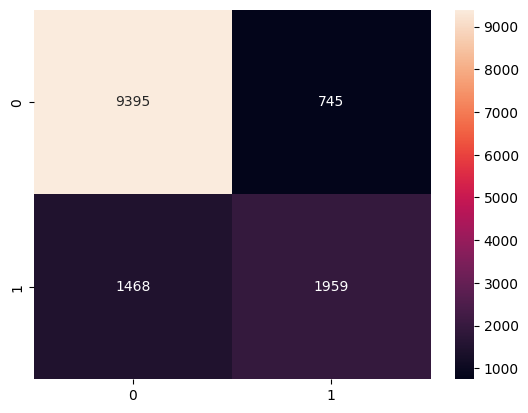

In [10]:
sns.heatmap(confusion_matrix, annot=True, fmt='g')

## Saving into DF then CSV

In [11]:
result_df = pd.DataFrame(results, columns=header)
result_df

,model_name,cv_seed,clas_acc,f1-micro,f1-macro,a1_dp,a1_deqodds,a1_deqopp,a1_TN_g0,a1_FP_g0,...,a2_FP_g0,a2_FN_g0,a2_TP_g0,a2_TN_g1,a2_FP_g1,a2_FN_g1,a2_TP_g1,wc_spd,wc_aod,wc_eod
0,SkVanillaLR,13,0.841675,0.841675,0.768517,0.818279,0.884024,0.845400,5711.0,611.0,...,623.0,1313.0,1743.0,1559.0,63.0,149.0,153.0,0.781435,0.837626,0.762049
1,SkVanillaLR,29,0.840495,0.840495,0.767970,0.815059,0.880982,0.841044,5682.0,627.0,...,646.0,1290.0,1764.0,1556.0,60.0,168.0,145.0,0.776405,0.850108,0.792715
2,SkVanillaLR,42,0.844254,0.844254,0.777531,0.802260,0.880576,0.848201,5580.0,671.0,...,677.0,1212.0,1861.0,1518.0,74.0,150.0,151.0,0.766773,0.856025,0.807542
3,SkVanillaLR,55,0.838063,0.838063,0.762863,0.827515,0.895599,0.858692,5722.0,564.0,...,589.0,1375.0,1720.0,1514.0,61.0,172.0,145.0,0.787834,0.846690,0.777469
4,SkVanillaLR,73,0.836884,0.836884,0.766841,0.809347,0.891470,0.865697,5599.0,658.0,...,689.0,1309.0,1826.0,1586.0,56.0,159.0,133.0,0.757357,0.838718,0.778966


In [12]:
result_df.to_csv(f'../results/{data_name}-unfair_lr-{epochs}.csv')